In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Data.csv")

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# **Data Preprocessing**

In [ ]:
df.shape

(5110, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


Replace vale of Male = 1 and Female = 0

In [ ]:
df["gender"].replace(["Male","Female"],[1,0], inplace=True)

<ipython-input-6-bfc5cc132f13>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].replace(["Male","Female"],[1,0], inplace=True)


Replace vale of ever_married Yes = 1 and No = 0

In [ ]:
df["ever_married"].replace(["Yes","No"],[1,0], inplace=True)

<ipython-input-7-33dbdb255d76>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ever_married"].replace(["Yes","No"],[1,0], inplace=True)
<ipython-input-7-33dbdb255d76>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["ever_married"].replace(["Yes","No"],[1,0], inplace=True)


In [ ]:
df[df["gender"]=="Other"]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,Other,26.0,0,0,0,Private,Rural,143.33,22.4,formerly smoked,0


In [ ]:
df.drop(index=3116, inplace=True)

In [ ]:
df.shape

(5109, 11)

In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


In [ ]:
isnull_number = []
for i in df.columns:
  x = df[i].isnull().sum()
  isnull_number.append(x)

pd.DataFrame(isnull_number, index= df.columns, columns = ["Total Missing values"])

,Total Missing values
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


In [ ]:
df[df["bmi"].isnull()]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,0,61.0,0,0,1,Self-employed,Rural,202.21,NaN,never smoked,1
8,0,59.0,0,0,1,Private,Rural,76.15,NaN,Unknown,1
13,1,78.0,0,1,1,Private,Urban,219.84,NaN,Unknown,1
19,1,57.0,0,1,0,Govt_job,Urban,217.08,NaN,Unknown,1
27,1,58.0,0,0,1,Private,Rural,189.84,NaN,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...
5039,1,41.0,0,0,0,Private,Rural,70.15,NaN,formerly smoked,0
5048,1,40.0,0,0,1,Private,Urban,191.15,NaN,smokes,0
5093,0,45.0,1,0,1,Govt_job,Rural,95.02,NaN,smokes,0
5099,1,40.0,0,0,1,Private,Rural,83.94,NaN,smokes,0


In [ ]:
df = df.ffill(axis=0)

<ipython-input-14-c848d70dddd6>:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.ffill(axis=0)


In [ ]:
isnull_number = []
for i in df.columns:
  x = df[i].isnull().sum()
  isnull_number.append(x)

pd.DataFrame(isnull_number, index= df.columns, columns = ["Total Missing values"])

,Total Missing values
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [ ]:
df["bmi"].isnull()

,bmi
0,False
1,False
2,False
3,False
4,False
...,...
5105,False
5106,False
5107,False
5108,False


In [ ]:
unique_values = []
for i in df.columns:
  x = df[i].value_counts().count()
  unique_values.append(x)
pd.DataFrame(unique_values, index=df.columns, columns=["Total Unique Values"])

,Total Unique Values
gender,2
age,104
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3978
bmi,418
smoking_status,4


In [ ]:
numeric_var = ["age", "avg_glucose_level", "bmi"]
categoric_var = ["gender","hypertension","heart_disease","ever_married","work_type","Residence_type","smoking_status","stroke"]

In [ ]:
df[numeric_var].describe()

,age,avg_glucose_level,bmi
count,5109.000000,5109.000000,5109.000000
mean,43.229986,106.140399,28.925974
std,22.613575,45.285004,7.839250
min,0.080000,55.120000,10.300000
25%,25.000000,77.240000,23.600000
50%,45.000000,91.880000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


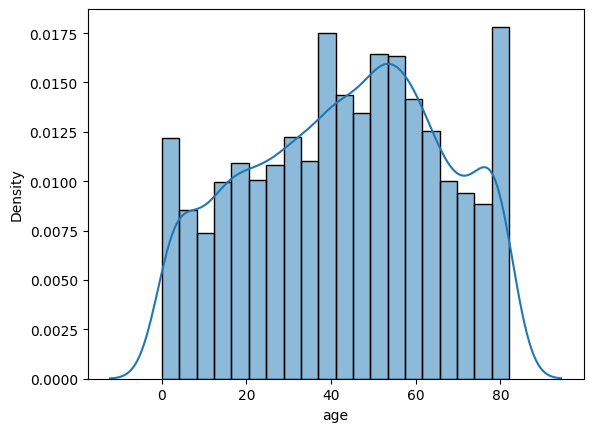

In [ ]:
sns.histplot(df["age"],kde=True, stat="density",kde_kws=dict(cut=3));

<Axes: xlabel='avg_glucose_level', ylabel='Density'>

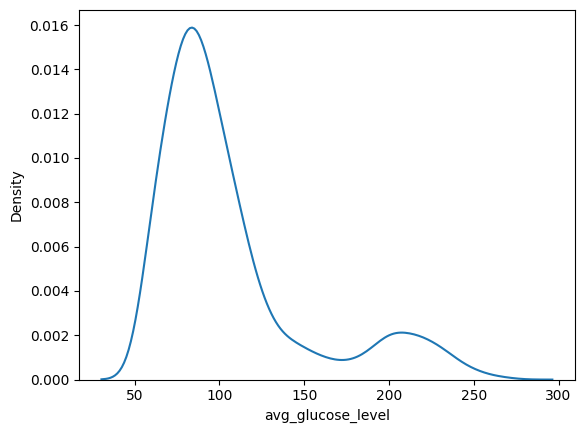

In [ ]:
sns.kdeplot(df["avg_glucose_level"])

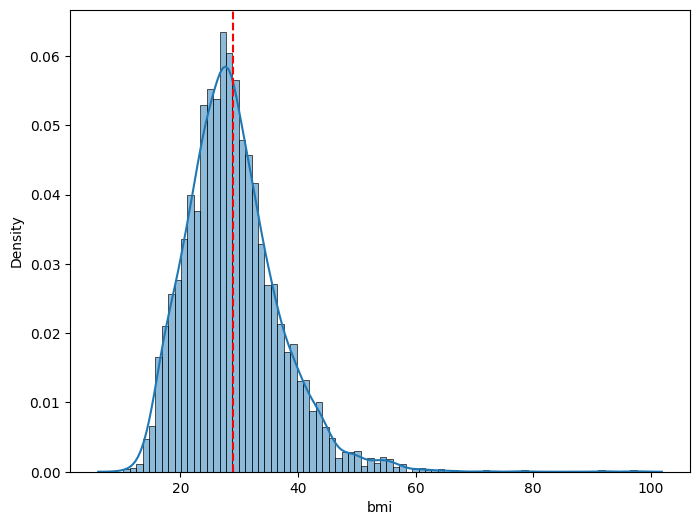

In [ ]:
x, y = plt.subplots(figsize = (8, 6))
sns.histplot(df["bmi"],kde=True, stat="density",kde_kws=dict(cut=3), ax=y);
y.axvline(df["bmi"].mean(), color = "r", ls = "--");

In [ ]:
numeric_var

['age', 'avg_glucose_level', 'bmi']

In [ ]:
numeric_axis_name=["Age of Patient", "Average Glucose Level", "Body Mass Index"]
list(zip(numeric_var,numeric_axis_name))

[('age', 'Age of Patient'),
 ('avg_glucose_level', 'Average Glucose Level'),
 ('bmi', 'Body Mass Index')]

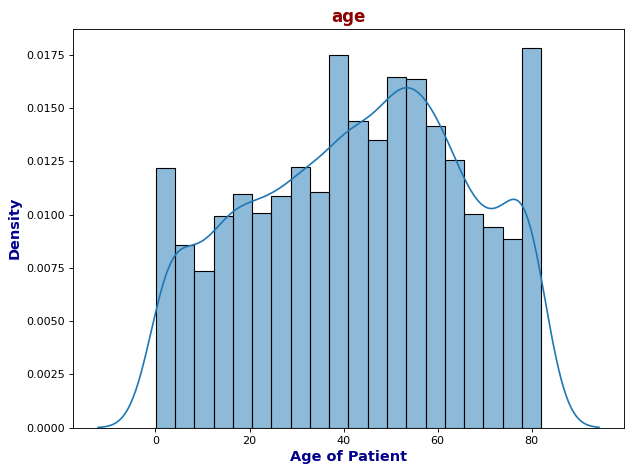

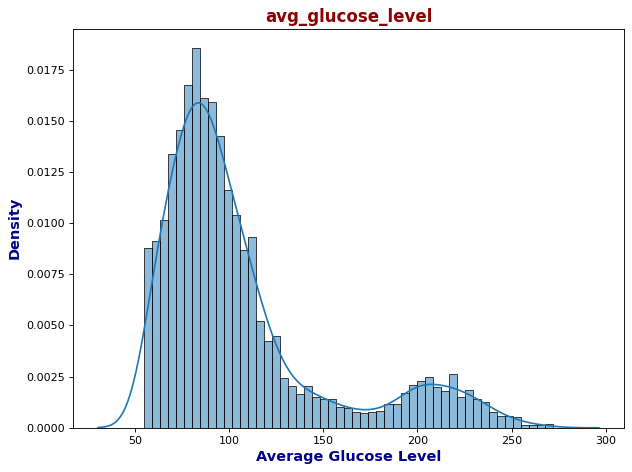

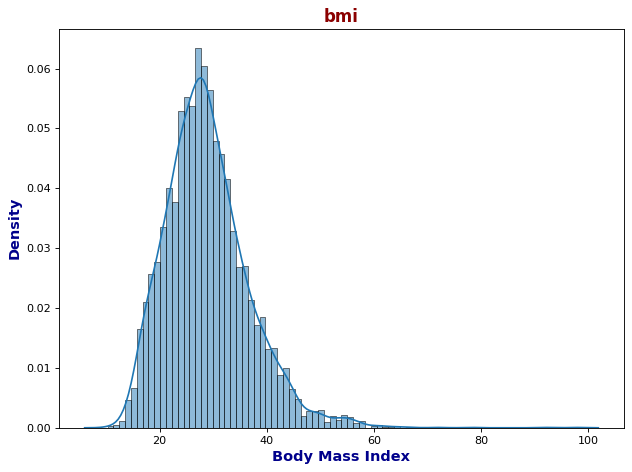

In [ ]:
title_font = {"family" : "sans-serif", "color" : "darkred", "weight" : "bold", "size" : 15}
axis_font = {"family" : "sans-serif", "color" : "darkblue", "weight" : "bold", "size" : 13}

for i, z in list(zip(numeric_var, numeric_axis_name)):
    plt.figure(figsize = (8, 6), dpi = 80)
    sns.histplot(df[i],kde=True, stat="density",kde_kws=dict(cut=3));

    plt.title(i, fontdict = title_font)
    plt.xlabel(z, fontdict = axis_font)
    plt.ylabel("Density", fontdict = axis_font)

    plt.tight_layout()
    plt.show()

Above histograms showcase that the data is mostly normally distributed throughout the dataset for different features.

In [ ]:
categoric_var

['gender',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'smoking_status',
 'stroke']

In [ ]:
categoric_axis_name=["Gender of Patient", "Hypertention", "Heart Disease History", "Patient Married or not","Sector of Work", "Type of Residence","Smoking History", "Patient had a stroke"]

In [ ]:
list(zip(categoric_var,categoric_axis_name))

[('gender', 'Gender of Patient'),
 ('hypertension', 'Hypertention'),
 ('heart_disease', 'Heart Disease History'),
 ('ever_married', 'Patient Married or not'),
 ('work_type', 'Sector of Work'),
 ('Residence_type', 'Type of Residence'),
 ('smoking_status', 'Smoking History'),
 ('stroke', 'Patient had a stroke')]

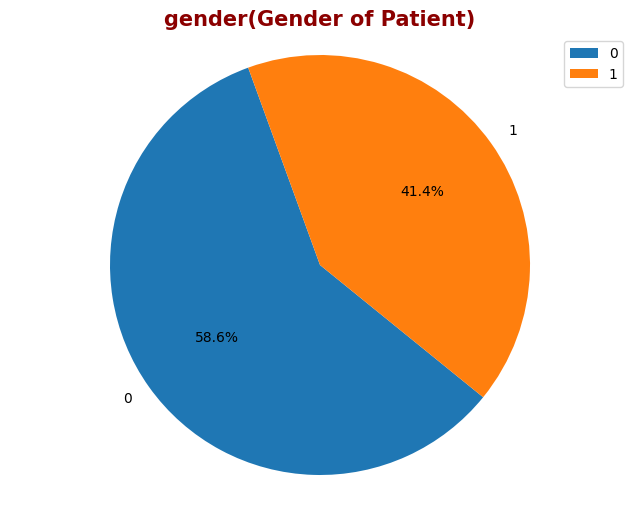

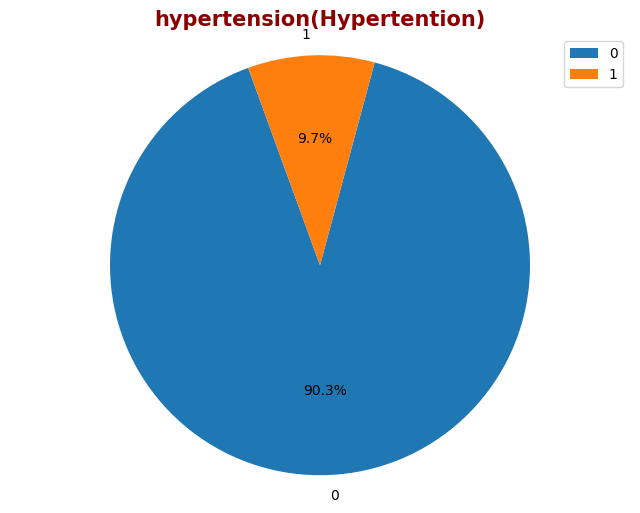

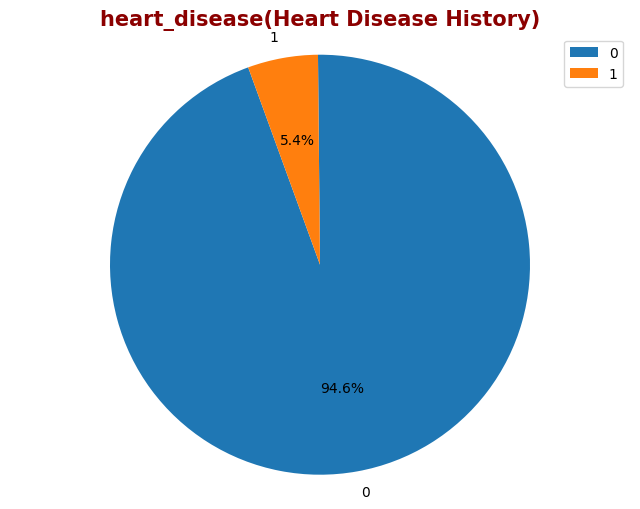

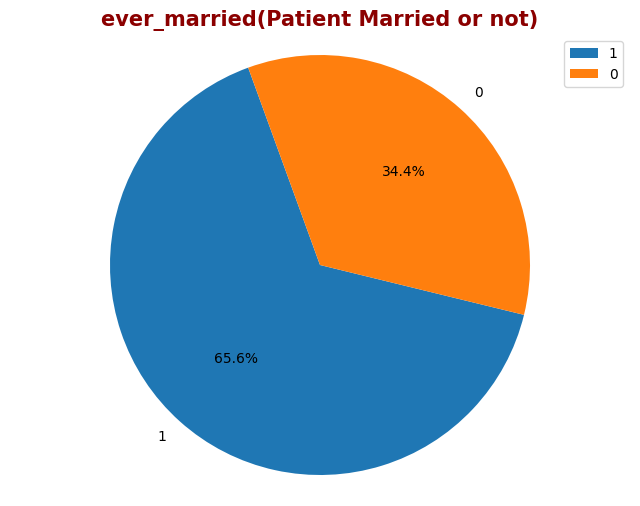

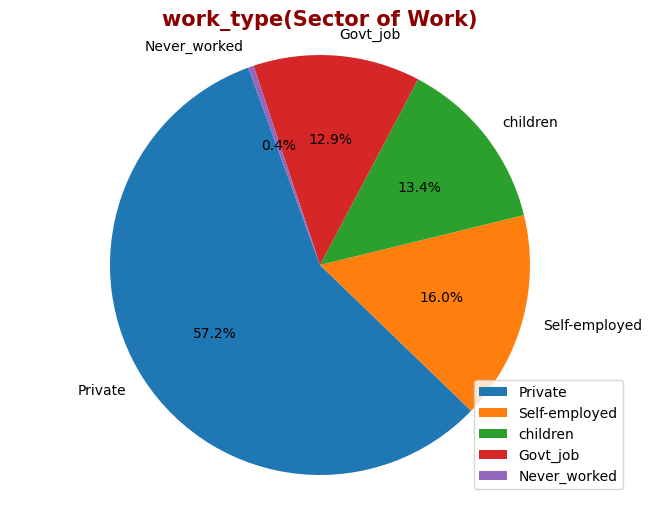

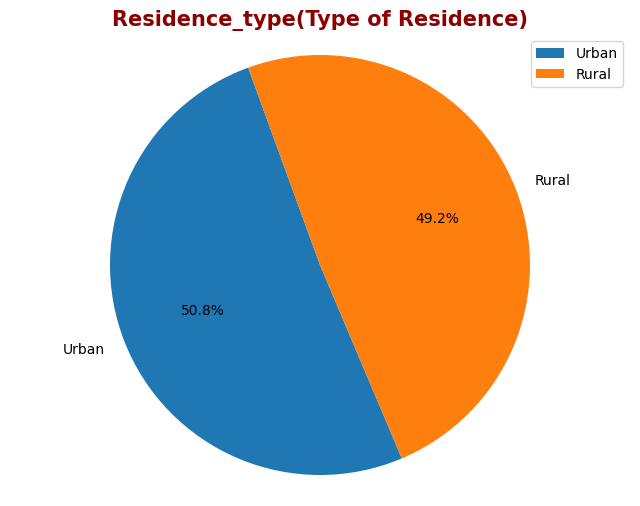

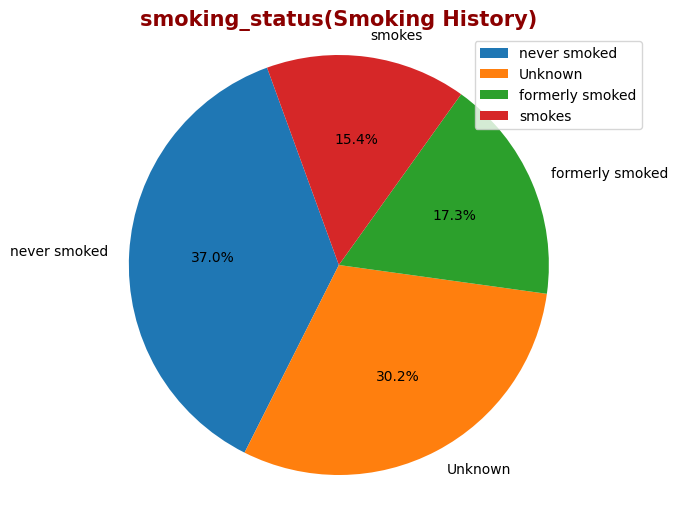

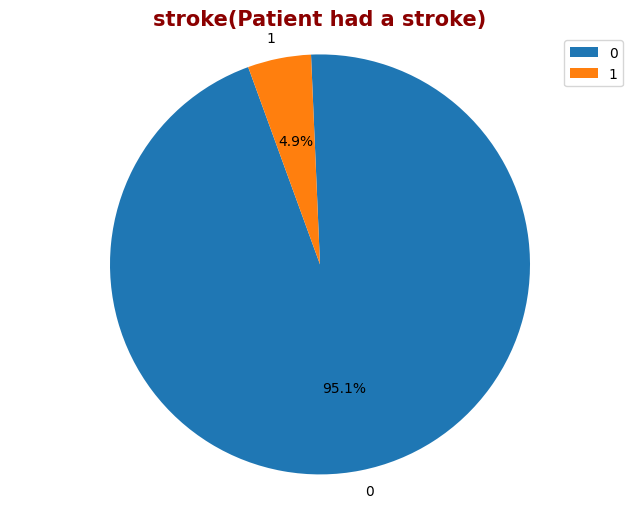

In [ ]:
for i, z in list(zip(categoric_var, categoric_axis_name)):
    fig, ax = plt.subplots(figsize = (8, 6))

    observation_values = list(df[i].value_counts().index)
    total_observation_values = list(df[i].value_counts())

    ax.pie(total_observation_values, labels= observation_values, autopct = '%1.1f%%', startangle = 110, labeldistance = 1.1)
    ax.axis("equal") # Equal aspect ratio ensures that pie is drawn as a circle.

    plt.title((i + "(" + z + ")"), fontdict = title_font) # Naming Pie Chart Titles
    plt.legend()
    plt.show()

For the smoking_status feature we will seperate the columns as the status of 30% of patient is Unknown which can impact the prediction.

In [ ]:
df_one = pd.get_dummies(df["smoking_status"])

In [ ]:
df_two = pd.concat((df_one,df),axis=1)

In [ ]:
df = df_two.drop(["smoking_status"],axis=1)

In [ ]:
df.replace({False: 0, True: 1}, inplace=True)
df.rename(columns={"Unknown": "non-smoker"})

<ipython-input-34-fb118edf18ac>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({False: 0, True: 1}, inplace=True)


,non-smoker,formerly smoked,never smoked,smokes,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,stroke
0,0,1,0,0,1,67.0,0,1,1,Private,Urban,228.69,36.6,1
1,0,0,1,0,0,61.0,0,0,1,Self-employed,Rural,202.21,36.6,1
2,0,0,1,0,1,80.0,0,1,1,Private,Rural,105.92,32.5,1
3,0,0,0,1,0,49.0,0,0,1,Private,Urban,171.23,34.4,1
4,0,0,1,0,0,79.0,1,0,1,Self-employed,Rural,174.12,24.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,0,0,1,0,0,80.0,1,0,1,Private,Urban,83.75,18.6,0
5106,0,0,1,0,0,81.0,0,0,1,Self-employed,Urban,125.20,40.0,0
5107,0,0,1,0,0,35.0,0,0,1,Self-employed,Rural,82.99,30.6,0
5108,0,1,0,0,1,51.0,0,0,1,Private,Rural,166.29,25.6,0


In [ ]:
df

,Unknown,formerly smoked,never smoked,smokes,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,stroke
0,0,1,0,0,1,67.0,0,1,1,Private,Urban,228.69,36.6,1
1,0,0,1,0,0,61.0,0,0,1,Self-employed,Rural,202.21,36.6,1
2,0,0,1,0,1,80.0,0,1,1,Private,Rural,105.92,32.5,1
3,0,0,0,1,0,49.0,0,0,1,Private,Urban,171.23,34.4,1
4,0,0,1,0,0,79.0,1,0,1,Self-employed,Rural,174.12,24.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,0,0,1,0,0,80.0,1,0,1,Private,Urban,83.75,18.6,0
5106,0,0,1,0,0,81.0,0,0,1,Self-employed,Urban,125.20,40.0,0
5107,0,0,1,0,0,35.0,0,0,1,Self-employed,Rural,82.99,30.6,0
5108,0,1,0,0,1,51.0,0,0,1,Private,Rural,166.29,25.6,0


Replace values of Residence_type Urban = 1 and Rural = 0

In [ ]:
df["Residence_type"].replace(["Urban","Rural",],[1,0], inplace=True)

<ipython-input-36-9aef5a160435>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Residence_type"].replace(["Urban","Rural",],[1,0], inplace=True)
<ipython-input-36-9aef5a160435>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Residence_type"].replace(["Urban","Rural",],[1,0], inplace=True)


In [ ]:
df["work_type"].replace(["Private","Self-employed","children","Govt_job","Never_worked"],[0,1,2,3,4], inplace=True)

<ipython-input-37-3227f3bba5cf>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["work_type"].replace(["Private","Self-employed","children","Govt_job","Never_worked"],[0,1,2,3,4], inplace=True)
<ipython-input-37-3227f3bba5cf>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["work_type"].replac

In [ ]:
df

,Unknown,formerly smoked,never smoked,smokes,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,stroke
0,0,1,0,0,1,67.0,0,1,1,0,1,228.69,36.6,1
1,0,0,1,0,0,61.0,0,0,1,1,0,202.21,36.6,1
2,0,0,1,0,1,80.0,0,1,1,0,0,105.92,32.5,1
3,0,0,0,1,0,49.0,0,0,1,0,1,171.23,34.4,1
4,0,0,1,0,0,79.0,1,0,1,1,0,174.12,24.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,0,0,1,0,0,80.0,1,0,1,0,1,83.75,18.6,0
5106,0,0,1,0,0,81.0,0,0,1,1,1,125.20,40.0,0
5107,0,0,1,0,0,35.0,0,0,1,1,0,82.99,30.6,0
5108,0,1,0,0,1,51.0,0,0,1,0,0,166.29,25.6,0


# **Bi-Variate Analysis**

In [ ]:
categoric_var.append("Unknown")
categoric_var.append("formerly smoked")
categoric_var.append("never smoked")
categoric_var.append("smokes")

In [ ]:
categoric_var = ['gender',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'stroke',
 'Unknown',
 'formerly smoked',
 'never smoked','smokes']

In [ ]:
categoric_axis_name = categoric_axis_name=["Gender of Patient", "Hypertention", "Heart Disease History", "Patient Married or not","Sector of Work", "Type of Residence","Patient had a stroke", "Unknown Smoking History","Formerly Used to Smoke","Never Smoked Before","Currently Smokes"]
list(zip(categoric_var,categoric_axis_name))

[('gender', 'Gender of Patient'),
 ('hypertension', 'Hypertention'),
 ('heart_disease', 'Heart Disease History'),
 ('ever_married', 'Patient Married or not'),
 ('work_type', 'Sector of Work'),
 ('Residence_type', 'Type of Residence'),
 ('stroke', 'Patient had a stroke'),
 ('Unknown', 'Unknown Smoking History'),
 ('formerly smoked', 'Formerly Used to Smoke'),
 ('never smoked', 'Never Smoked Before'),
 ('smokes', 'Currently Smokes')]

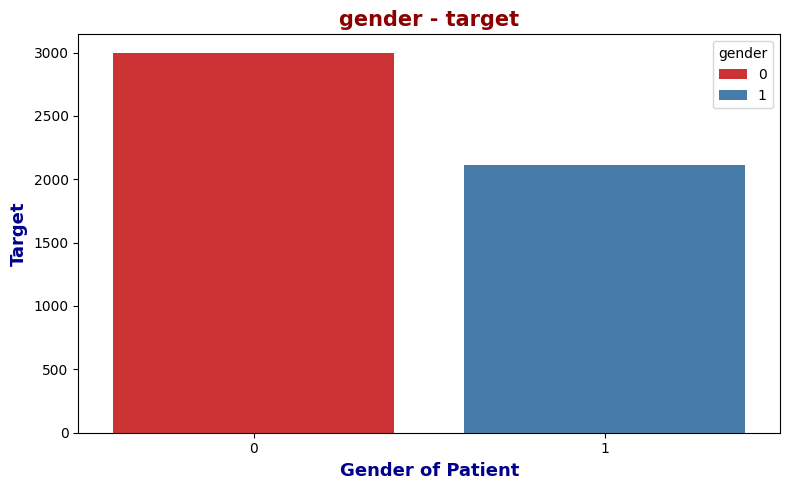

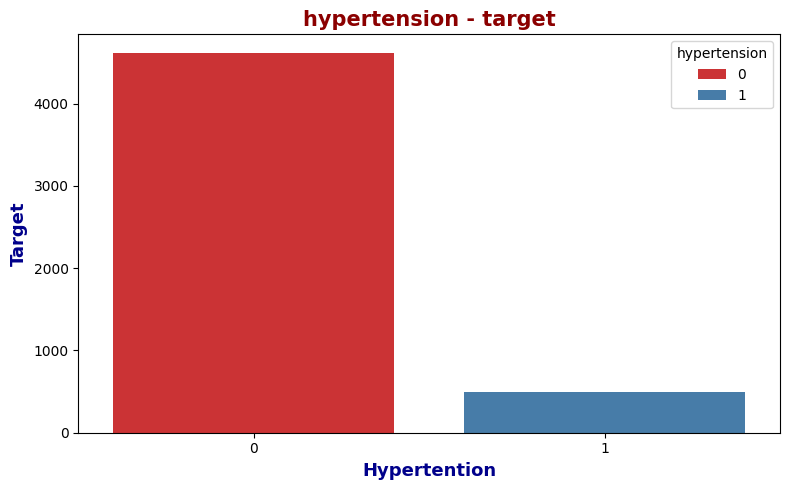

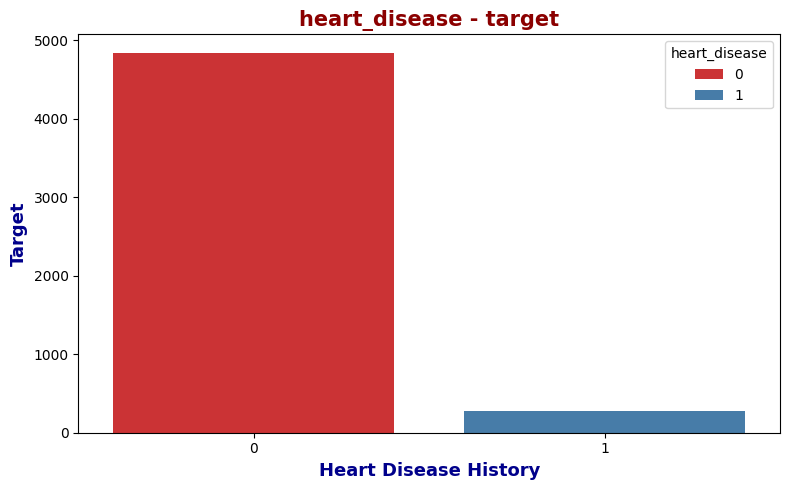

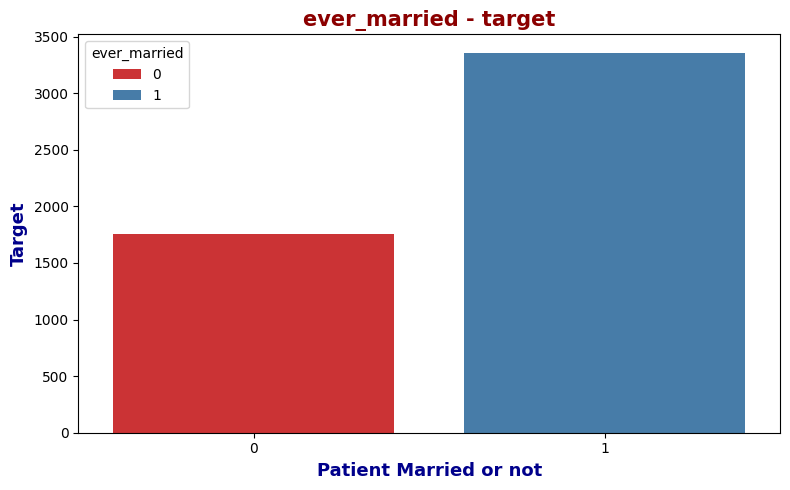

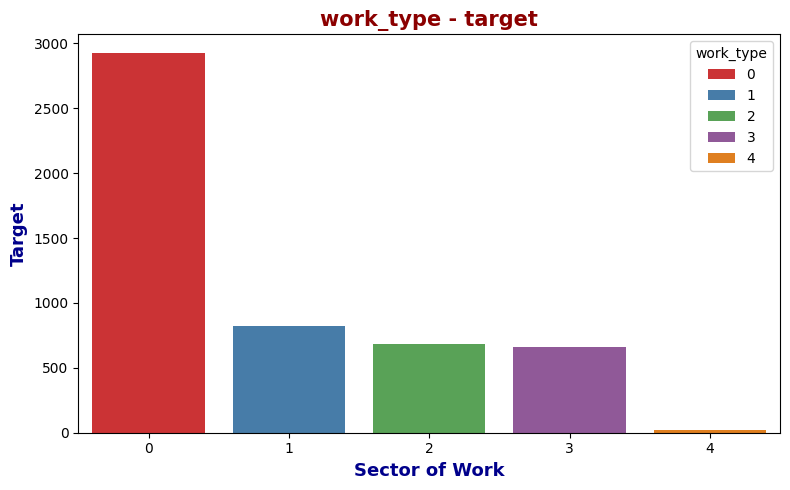

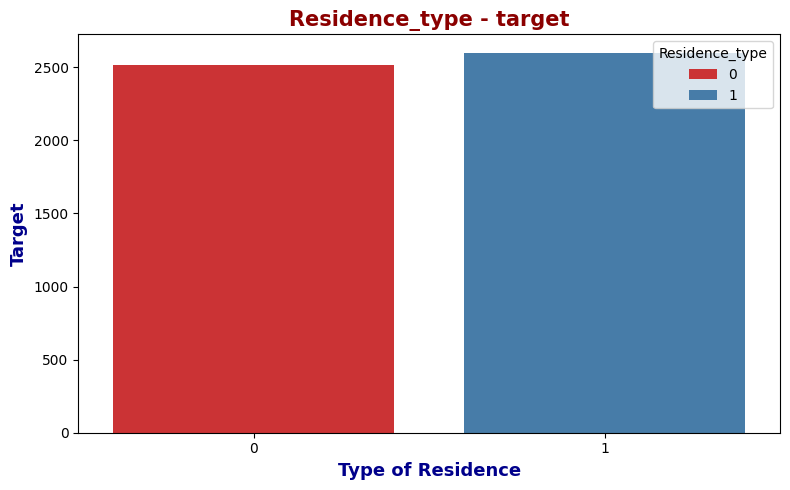

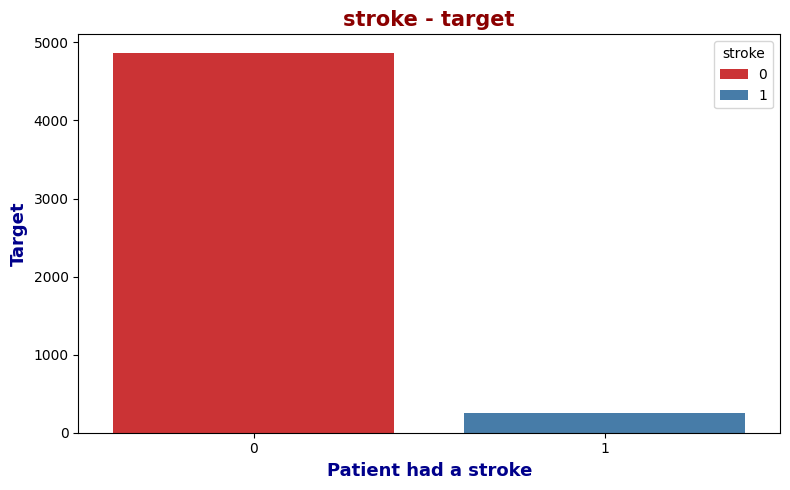

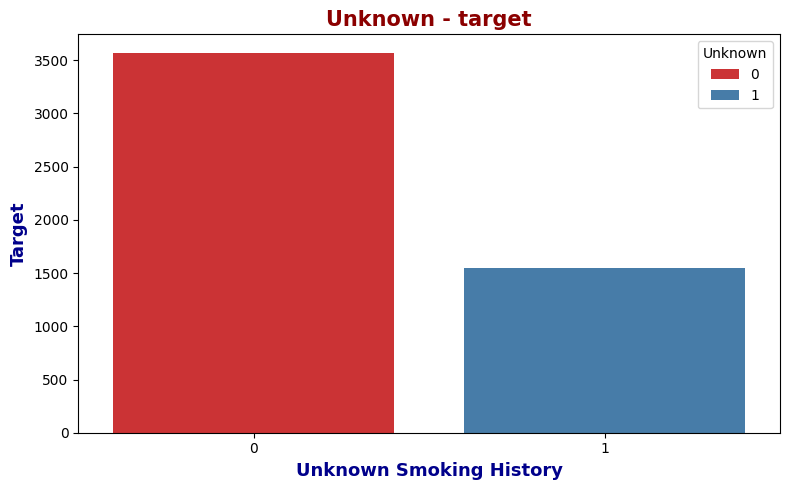

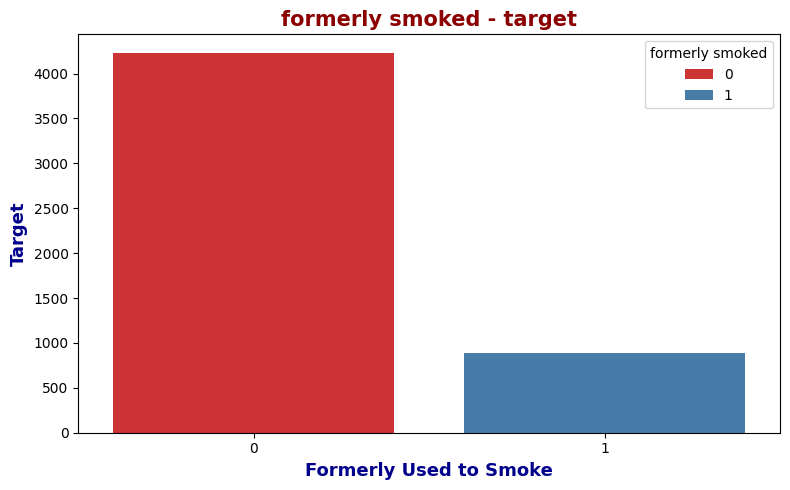

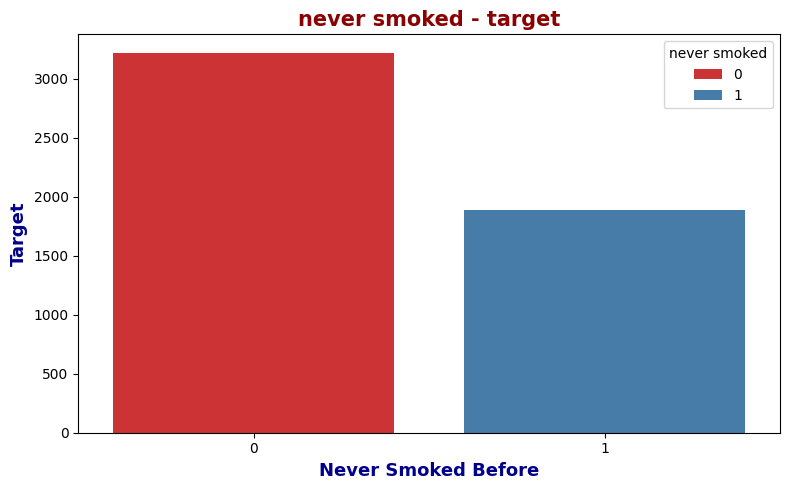

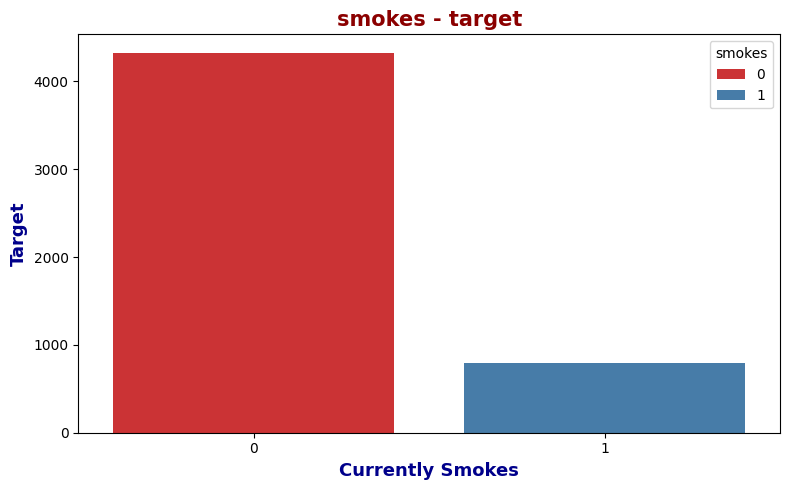

In [ ]:
title_font = {"family" : "sans-serif", "color" : "darkred", "weight" : "bold", "size" : 15}
axis_font = {"family" : "sans-serif", "color" : "darkblue", "weight" : "bold", "size" : 13}

for i,z in list(zip(categoric_var,categoric_axis_name)):
    plt.figure(figsize = (8,5))
    sns.countplot(x=df[i], data = df[categoric_var], palette = 'Set1', hue=df[i])

    plt.title(i + " - target", fontdict = title_font)
    plt.xlabel(z, fontdict = axis_font)
    plt.ylabel("Target", fontdict = axis_font)

    plt.tight_layout()
    plt.show()

# **Correlation Plot**

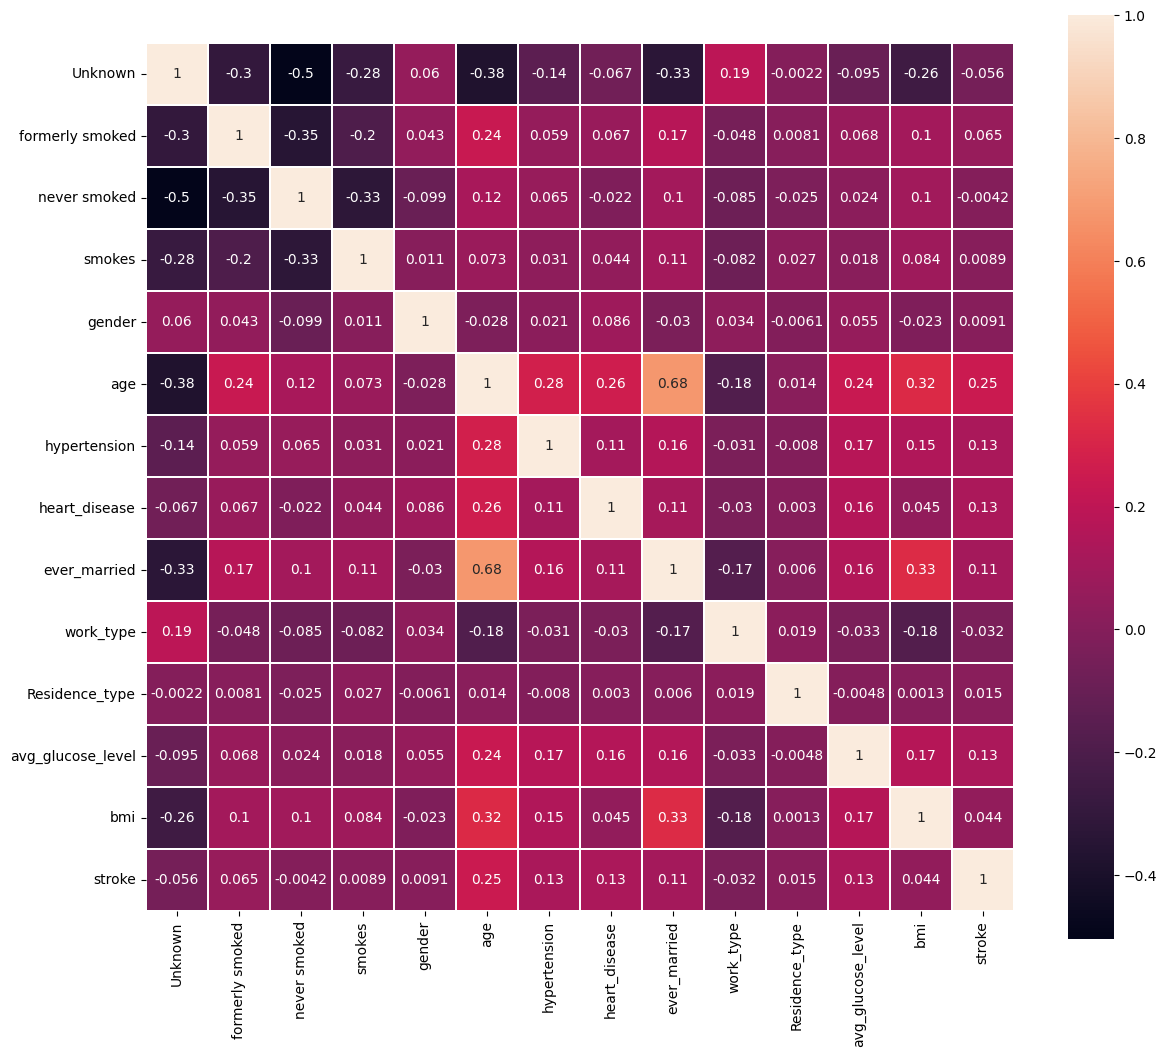

In [ ]:
plt.figure(figsize=(14,12))
sns.heatmap(df.astype(float).corr(),linewidths=0.1,
            square=True,  linecolor='white', annot=True)
plt.show()

In [ ]:
df[categoric_var].corr().iloc[:, [-5]]


,stroke
gender,0.009081
hypertension,0.127891
heart_disease,0.134905
ever_married,0.108299
work_type,-0.032133
Residence_type,0.015415
stroke,1.000000
Unknown,-0.055924
formerly smoked,0.064683
never smoked,-0.004163


Remove outliers so that data can be streamlined

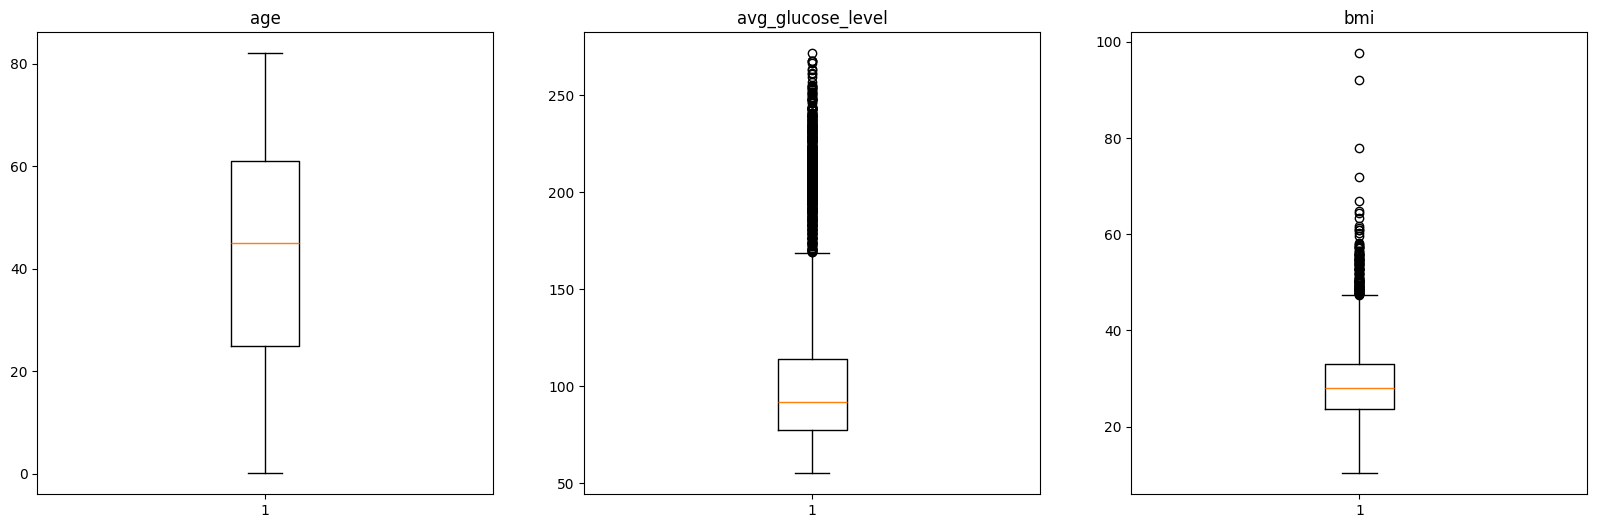

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (20, 6))

ax1.boxplot(df["age"])
ax1.set_title("age")

ax2.boxplot(df["avg_glucose_level"])
ax2.set_title("avg_glucose_level")

ax3.boxplot(df["bmi"])
ax3.set_title("bmi")

plt.show()

In [ ]:
def iqr(df, var):
    q1 = np.quantile(df[var],0.25)
    q3 = np.quantile(df[var],0.75)
    diff = q3 - q1

    lower_v = q1 - (1.5*diff)
    upper_v = q3 + (1.5*diff)
    return df[(df[var] < lower_v) | (df[var] > upper_v)]

In [ ]:
iqr(df, "bmi")

,Unknown,formerly smoked,never smoked,smokes,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,stroke
21,0,0,1,0,0,52.0,1,0,1,1,1,233.29,48.9,1
66,0,0,1,0,0,70.0,0,0,1,0,1,221.58,47.5,1
113,0,0,1,0,0,45.0,0,0,1,0,0,224.10,56.6,1
254,1,0,0,0,0,47.0,0,0,1,0,1,210.95,50.1,0
258,0,0,1,0,0,74.0,1,0,1,1,1,205.84,54.6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4858,0,0,0,1,0,43.0,0,0,1,0,1,100.88,47.6,0
4906,0,0,1,0,0,53.0,0,0,1,0,1,70.51,54.1,0
4952,0,0,1,0,1,51.0,1,0,1,1,0,211.83,56.6,0
5009,0,1,0,0,0,50.0,0,0,1,1,0,126.85,49.5,0


In [ ]:
from scipy import stats
from scipy.stats import zscore
from scipy.stats.mstats import winsorize

In [ ]:
z_scores_avg_glucose = zscore(df["avg_glucose_level"])
for threshold in range(1, 4):
    print("Threshold Value: {}".format(threshold))
    print("Number of Outliers: {}".format(len(np.where(z_scores_avg_glucose > threshold)[0])))
    print("-------------------")

Threshold Value: 1
Number of Outliers: 718
-------------------
Threshold Value: 2
Number of Outliers: 471
-------------------
Threshold Value: 3
Number of Outliers: 49
-------------------


In [ ]:
df[z_scores_avg_glucose > 3][["avg_glucose_level"]].count()

,0
avg_glucose_level,49


In [ ]:
df[z_scores_avg_glucose > 3].avg_glucose_level.min()

242.3

In [ ]:
df[df["avg_glucose_level"] < 242.3].avg_glucose_level.max()

240.86

In [ ]:
winsorize_percentile_avg_glucose = (stats.percentileofscore(df["avg_glucose_level"], 240.86)) / 100
print(winsorize_percentile_avg_glucose)

0.9904090820121354


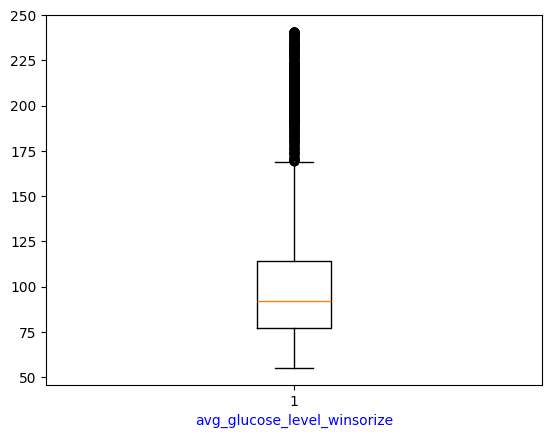

In [ ]:
avg_glucose_level_winsorize = winsorize(df.avg_glucose_level, (0, (1 - winsorize_percentile_avg_glucose)))

plt.boxplot(avg_glucose_level_winsorize)
plt.xlabel("avg_glucose_level_winsorize", color = "b")
plt.show()

In [ ]:
df["avg_glucose_level_winsorize"] = avg_glucose_level_winsorize

In [ ]:
iqr(df, "bmi")

,Unknown,formerly smoked,never smoked,smokes,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,stroke,avg_glucose_level_winsorize
21,0,0,1,0,0,52.0,1,0,1,1,1,233.29,48.9,1,233.29
66,0,0,1,0,0,70.0,0,0,1,0,1,221.58,47.5,1,221.58
113,0,0,1,0,0,45.0,0,0,1,0,0,224.10,56.6,1,224.10
254,1,0,0,0,0,47.0,0,0,1,0,1,210.95,50.1,0,210.95
258,0,0,1,0,0,74.0,1,0,1,1,1,205.84,54.6,0,205.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4858,0,0,0,1,0,43.0,0,0,1,0,1,100.88,47.6,0,100.88
4906,0,0,1,0,0,53.0,0,0,1,0,1,70.51,54.1,0,70.51
4952,0,0,1,0,1,51.0,1,0,1,1,0,211.83,56.6,0,211.83
5009,0,1,0,0,0,50.0,0,0,1,1,0,126.85,49.5,0,126.85


In [ ]:
z_scores_bmi = zscore(df["bmi"])
for threshold in range(1, 4):
    print("Threshold Value: {}".format(threshold))
    print("Number of Outliers: {}".format(len(np.where(z_scores_bmi > threshold)[0])))
    print("-------------------")

Threshold Value: 1
Number of Outliers: 727
-------------------
Threshold Value: 2
Number of Outliers: 178
-------------------
Threshold Value: 3
Number of Outliers: 60
-------------------


In [ ]:
df[z_scores_bmi > 3][["bmi"]].count()

,0
bmi,60


In [ ]:
df[z_scores_bmi > 3].bmi.min()

52.5

In [ ]:
df[df["bmi"] < 52.5].bmi.max()

52.3

In [ ]:
winsorize_percentile_bmi = (stats.percentileofscore(df["bmi"], 52.3)) / 100
print(winsorize_percentile_bmi)

0.9882560187903698


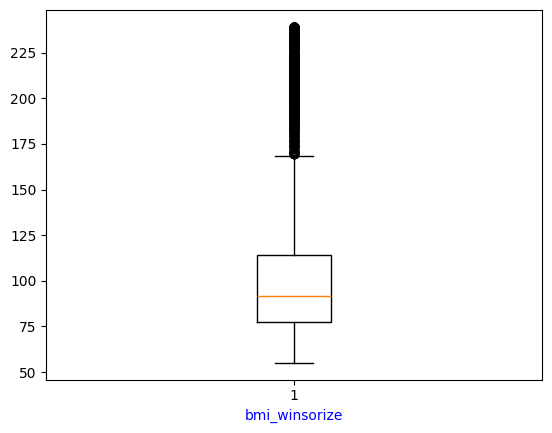

In [ ]:
bmi_winsorize = winsorize(df.avg_glucose_level, (0, (1 - winsorize_percentile_bmi)))

plt.boxplot(bmi_winsorize)
plt.xlabel("bmi_winsorize", color = "b")
plt.show()

In [ ]:
df["bmi_winsorize"] = bmi_winsorize

In [ ]:
df.head()

,Unknown,formerly smoked,never smoked,smokes,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,stroke,avg_glucose_level_winsorize,bmi_winsorize
0,0,1,0,0,1,67.0,0,1,1,0,1,228.69,36.6,1,228.69,228.69
1,0,0,1,0,0,61.0,0,0,1,1,0,202.21,36.6,1,202.21,202.21
2,0,0,1,0,1,80.0,0,1,1,0,0,105.92,32.5,1,105.92,105.92
3,0,0,0,1,0,49.0,0,0,1,0,1,171.23,34.4,1,171.23,171.23
4,0,0,1,0,0,79.0,1,0,1,1,0,174.12,24.0,1,174.12,174.12


 Determining Distributions of Numeric Variables

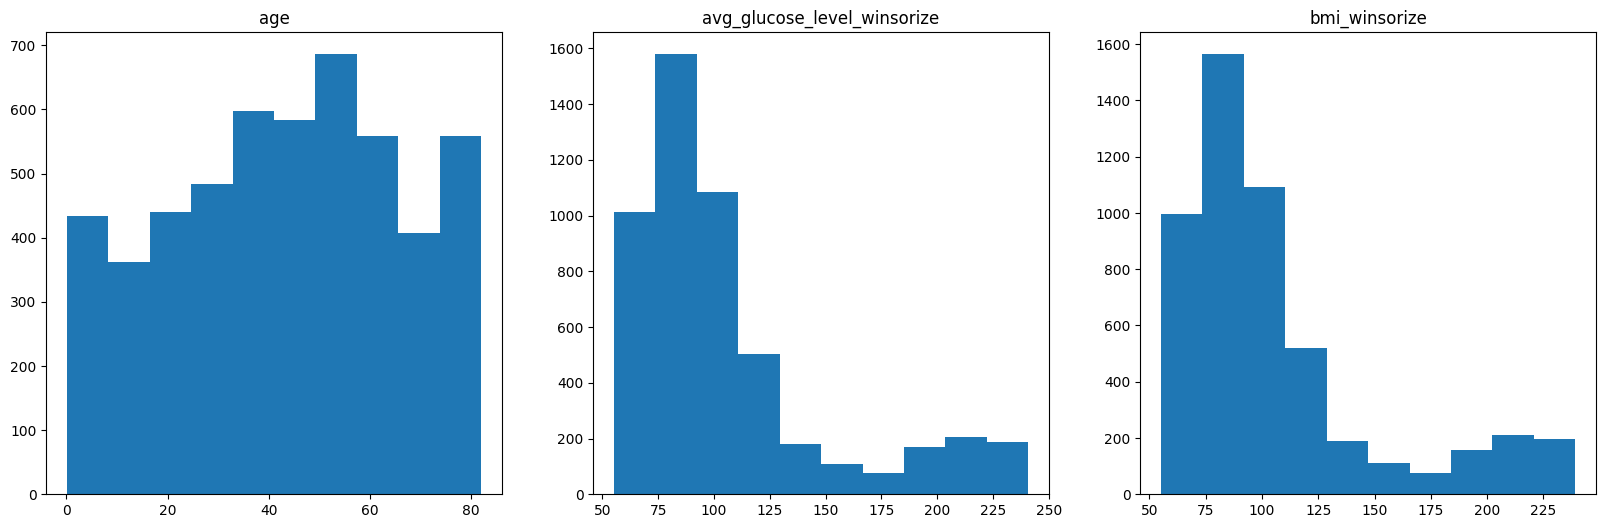

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (20, 6))

ax1.hist(df["age"])
ax1.set_title("age")

ax2.hist(df["avg_glucose_level_winsorize"])
ax2.set_title("avg_glucose_level_winsorize")

ax3.hist(df["bmi_winsorize"])
ax3.set_title("bmi_winsorize")

plt.show()

In [ ]:
df[["age", "avg_glucose_level_winsorize", "bmi_winsorize"]].agg(["skew"]).transpose()

,skew
age,-0.137430
avg_glucose_level_winsorize,1.543977
bmi_winsorize,1.540031


The skewness of both avg_glucose_level_winsorize & bmi_winsorize is >1 hence they need to be tranformed into log and sqrt

In [ ]:
df["avg_glucose_level_winsorize_log"] = np.log(df["avg_glucose_level_winsorize"])
df["avg_glucose_level_winsorize_sqrt"] = np.sqrt(df["avg_glucose_level_winsorize"])
df["avg_glucose_level_winsorize_cbrt"] = np.cbrt(df["avg_glucose_level_winsorize"])
df["avg_glucose_level_winsorize_log10"] = np.log10(df["avg_glucose_level_winsorize"])

df["bmi_winsorize_log"] = np.log(df["bmi_winsorize"])
df["bmi_winsorize_sqrt"] = np.sqrt(df["bmi_winsorize"])
df["bmi_winsorize_cbrt"] = np.cbrt(df["bmi_winsorize"])
df["bmi_winsorize_log10"] = np.log10(df["bmi_winsorize"])

In [ ]:
df.head()

,Unknown,formerly smoked,never smoked,smokes,gender,age,hypertension,heart_disease,ever_married,work_type,...,avg_glucose_level_winsorize,bmi_winsorize,avg_glucose_level_winsorize_log,avg_glucose_level_winsorize_sqrt,avg_glucose_level_winsorize_cbrt,avg_glucose_level_winsorize_log10,bmi_winsorize_log,bmi_winsorize_sqrt,bmi_winsorize_cbrt,bmi_winsorize_log10
0,0,1,0,0,1,67.0,0,1,1,0,...,228.69,228.69,5.432367,15.122500,6.115271,2.359247,5.432367,15.122500,6.115271,2.359247
1,0,0,1,0,0,61.0,0,0,1,1,...,202.21,202.21,5.309307,14.220056,5.869497,2.305803,5.309307,14.220056,5.869497,2.305803
2,0,0,1,0,1,80.0,0,1,1,0,...,105.92,105.92,4.662684,10.291744,4.731433,2.024978,4.662684,10.291744,4.731433,2.024978
3,0,0,0,1,0,49.0,0,0,1,0,...,171.23,171.23,5.143008,13.085488,5.552987,2.233580,5.143008,13.085488,5.552987,2.233580
4,0,0,1,0,0,79.0,1,0,1,1,...,174.12,174.12,5.159745,13.195454,5.584053,2.240849,5.159745,13.195454,5.584053,2.240849


In [ ]:
df[["avg_glucose_level_winsorize", "avg_glucose_level_winsorize_log", "avg_glucose_level_winsorize_sqrt","avg_glucose_level_winsorize_cbrt","avg_glucose_level_winsorize_log10","bmi_winsorize", "bmi_winsorize_log", "bmi_winsorize_sqrt","bmi_winsorize_cbrt","bmi_winsorize_log10"]].agg(["skew"]).transpose()

,skew
avg_glucose_level_winsorize,1.543977
avg_glucose_level_winsorize_log,0.871777
avg_glucose_level_winsorize_sqrt,1.224833
avg_glucose_level_winsorize_cbrt,1.110372
avg_glucose_level_winsorize_log10,0.871777
bmi_winsorize,1.540031
bmi_winsorize_log,0.869963
bmi_winsorize_sqrt,1.222113
bmi_winsorize_cbrt,1.107986
bmi_winsorize_log10,0.869963


In [ ]:
df.drop(["avg_glucose_level_winsorize", "avg_glucose_level_winsorize_sqrt","avg_glucose_level_winsorize_cbrt","avg_glucose_level_winsorize_log10","bmi_winsorize", "bmi_winsorize_sqrt","bmi_winsorize_cbrt","bmi_winsorize_log10"], axis = 1, inplace = True)

In [ ]:
df.head()

,Unknown,formerly smoked,never smoked,smokes,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,stroke,avg_glucose_level_winsorize_log,bmi_winsorize_log
0,0,1,0,0,1,67.0,0,1,1,0,1,228.69,36.6,1,5.432367,5.432367
1,0,0,1,0,0,61.0,0,0,1,1,0,202.21,36.6,1,5.309307,5.309307
2,0,0,1,0,1,80.0,0,1,1,0,0,105.92,32.5,1,4.662684,4.662684
3,0,0,0,1,0,49.0,0,0,1,0,1,171.23,34.4,1,5.143008,5.143008
4,0,0,1,0,0,79.0,1,0,1,1,0,174.12,24.0,1,5.159745,5.159745


# **One hot encoding method for categorical data**

In [ ]:
dfextra = df.copy()

In [ ]:
dfextra.head()

,Unknown,formerly smoked,never smoked,smokes,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,stroke,avg_glucose_level_winsorize_log,bmi_winsorize_log
0,0,1,0,0,1,67.0,0,1,1,0,1,228.69,36.6,1,5.432367,5.432367
1,0,0,1,0,0,61.0,0,0,1,1,0,202.21,36.6,1,5.309307,5.309307
2,0,0,1,0,1,80.0,0,1,1,0,0,105.92,32.5,1,4.662684,4.662684
3,0,0,0,1,0,49.0,0,0,1,0,1,171.23,34.4,1,5.143008,5.143008
4,0,0,1,0,0,79.0,1,0,1,1,0,174.12,24.0,1,5.159745,5.159745


In [ ]:
categoric_var

['gender',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'Residence_type',
 'stroke',
 'Unknown',
 'formerly smoked',
 'never smoked',
 'smokes']

In [ ]:
dfextra = pd.get_dummies(dfextra, columns = categoric_var[:-1], drop_first = True, dtype=int)

In [ ]:
dfextra.head()

,smokes,age,avg_glucose_level,bmi,avg_glucose_level_winsorize_log,bmi_winsorize_log,gender_1,hypertension_1,heart_disease_1,ever_married_1,work_type_1,work_type_2,work_type_3,work_type_4,Residence_type_1,stroke_1,Unknown_1,formerly smoked_1,never smoked_1
0,0,67.0,228.69,36.6,5.432367,5.432367,1,0,1,1,0,0,0,0,1,1,0,1,0
1,0,61.0,202.21,36.6,5.309307,5.309307,0,0,0,1,1,0,0,0,0,1,0,0,1
2,0,80.0,105.92,32.5,4.662684,4.662684,1,0,1,1,0,0,0,0,0,1,0,0,1
3,1,49.0,171.23,34.4,5.143008,5.143008,0,0,0,1,0,0,0,0,1,1,0,0,0
4,0,79.0,174.12,24.0,5.159745,5.159745,0,1,0,1,1,0,0,0,0,1,0,0,1


In [ ]:
new_numeric_var = ["age", "avg_glucose_level_winsorize_log","bmi_winsorize_log"]

Data is scalled using RobustScaler so as to scale the data according to the IQR

In [ ]:
from sklearn.preprocessing import RobustScaler

In [ ]:
robust_scaler = RobustScaler()
dfextra[new_numeric_var] = robust_scaler.fit_transform(dfextra[new_numeric_var])

In [ ]:
dfextra.head()

,smokes,age,avg_glucose_level,bmi,avg_glucose_level_winsorize_log,bmi_winsorize_log,gender_1,hypertension_1,heart_disease_1,ever_married_1,work_type_1,work_type_2,work_type_3,work_type_4,Residence_type_1,stroke_1,Unknown_1,formerly smoked_1,never smoked_1
0,0,0.611111,228.69,36.6,2.337744,2.337744,1,0,1,1,0,0,0,0,1,1,0,1,0
1,0,0.444444,202.21,36.6,2.022260,2.022260,0,0,0,1,1,0,0,0,0,1,0,0,1
2,0,0.972222,105.92,32.5,0.364552,0.364552,1,0,1,1,0,0,0,0,0,1,0,0,1
3,1,0.111111,171.23,34.4,1.595929,1.595929,0,0,0,1,0,0,0,0,1,1,0,0,0
4,0,0.944444,174.12,24.0,1.638837,1.638837,0,1,0,1,1,0,0,0,0,1,0,0,1


Split the data into training and test data so as to check accuracy against a new data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = dfextra.drop(["stroke_1"],axis=1)
y = dfextra[["stroke_1"]]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=48)

In [ ]:
x_train.head()

,smokes,age,avg_glucose_level,bmi,avg_glucose_level_winsorize_log,bmi_winsorize_log,gender_1,hypertension_1,heart_disease_1,ever_married_1,work_type_1,work_type_2,work_type_3,work_type_4,Residence_type_1,Unknown_1,formerly smoked_1,never smoked_1
1363,0,0.472222,126.99,29.4,0.829658,0.829658,0,0,0,1,0,0,0,0,0,0,1,0
4821,0,-0.305556,68.53,29.7,-0.751690,-0.751690,0,0,0,1,1,0,0,0,0,0,0,1
807,0,0.166667,116.14,20.9,0.600694,0.600694,0,0,0,0,0,0,1,0,0,0,0,1
4284,0,0.666667,78.11,34.7,-0.416246,-0.416246,1,1,1,1,0,0,0,0,1,0,1,0
1954,0,0.194444,102.97,41.9,0.292138,0.292138,1,0,1,1,1,0,0,0,0,0,1,0


In [ ]:
y_train.head()

,stroke_1
1363,0
4821,0
807,0
4284,0
1954,0


In [ ]:
y_train[y_train["stroke_1"]==1].count()

,0
stroke_1,225


In [ ]:
print(f"X_train: {x_train.shape[0]}")
print(f"X_test: {x_test.shape[0]}")
print(f"y_train: {y_train.shape[0]}")
print(f"y_test: {y_test.shape[0]}")

X_train: 4598
X_test: 511
y_train: 4598
y_test: 511


# **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
log_reg = LogisticRegression(solver='lbfgs', max_iter=1000)
log_reg

LogisticRegression(max_iter=1000)

In [ ]:
log_reg.fit(x_train, y_train.values.ravel())

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = log_reg.predict(x_test)

In [ ]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy: {}".format(accuracy))

Test Accuracy: 0.9530332681017613


**Cross Validation for Logistic Regression Model**

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
scores = cross_val_score(log_reg, x_test, y_test.values.ravel(), cv = 10)
print("Cross-Validation Accuracy Scores", scores.mean())

Cross-Validation Accuracy Scores 0.9530542986425339


**Roc Curve and Area Under Curve(AUC)**

In [ ]:
from sklearn.metrics import roc_curve, auc

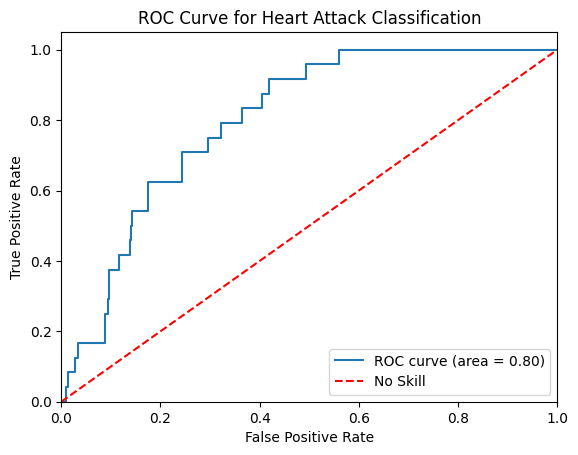

In [ ]:
probs = log_reg.predict_proba(x_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'r--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Heart Attack Classification')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
log_reg_new = LogisticRegression()
log_reg_new

LogisticRegression()

In [ ]:
parameters = {"penalty":["l1","l2"], "solver" : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

In [ ]:
log_reg_grid = GridSearchCV(log_reg_new, param_grid = parameters)

In [ ]:
log_reg_grid.fit(x_train, y_train.values.ravel())

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'penalty': ['l1', 'l2'],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']})

In [ ]:
print("Best Parameters: ", log_reg_grid.best_params_)

Best Parameters:  {'penalty': 'l1', 'solver': 'liblinear'}


In [ ]:
log_reg_new2 = LogisticRegression(penalty = "l1", solver = "liblinear")
log_reg_new2

LogisticRegression(penalty='l1', solver='liblinear')

In [ ]:
log_reg_new2.fit(x_train, y_train.values.ravel())

LogisticRegression(penalty='l1', solver='liblinear')

In [ ]:
y_pred_new2 = log_reg_new2.predict(x_test)

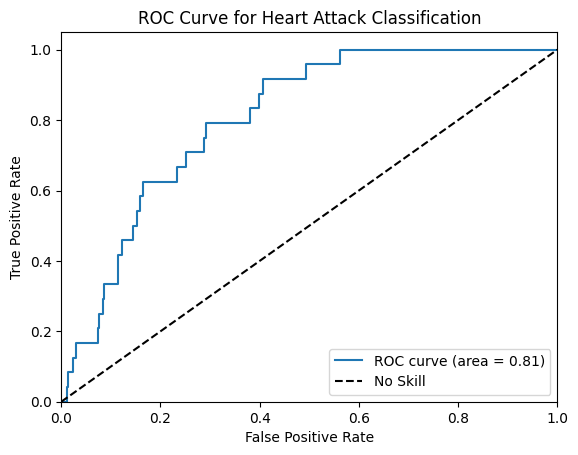

In [ ]:
probs = log_reg_new2.predict_proba(x_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Heart Attack Classification')
plt.legend()
plt.show()

# **Decision Tree Algorithm**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dec_tree = DecisionTreeClassifier(random_state = 5)
dec_tree.fit(x_train, y_train)

DecisionTreeClassifier(random_state=5)

In [ ]:
y_pred = dec_tree.predict(x_test)
print("The test accuracy score of Decision Tree is:", accuracy_score(y_test, y_pred))

The test accuracy score of Decision Tree is: 0.9178082191780822


In [ ]:
scores = cross_val_score(dec_tree, x_test, y_test, cv = 10)
print("Cross-Validation Accuracy Scores", scores.mean())

Cross-Validation Accuracy Scores 0.8963046757164405


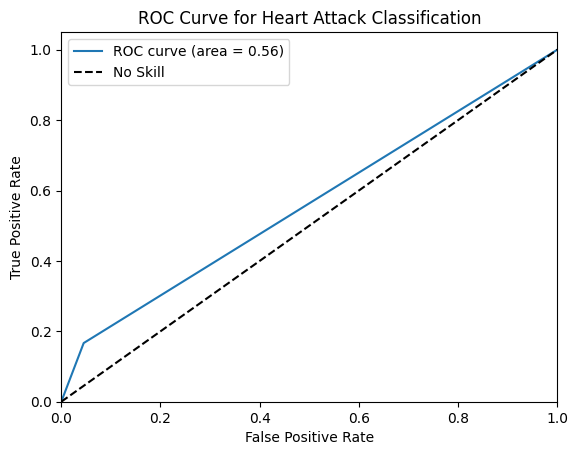

In [ ]:
probs = dec_tree.predict_proba(x_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Heart Attack Classification')
plt.legend()
plt.show()

# **Support Vector Machine Algorithm**

In [ ]:
from sklearn.svm import SVC
svc_model = SVC(random_state = 5,probability=True)
svc_model.fit(x_train, y_train.values.ravel())

SVC(probability=True, random_state=5)

In [ ]:
y_pred = svc_model.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
print("The test accuracy score of SVM is:", accuracy_score(y_test, y_pred))

The test accuracy score of SVM is: 0.9530332681017613


In [ ]:
scores = cross_val_score(svc_model, x_test, y_test.values.ravel(), cv = 10)
print("Cross-Validation Accuracy Scores", scores.mean())

Cross-Validation Accuracy Scores 0.9530542986425339


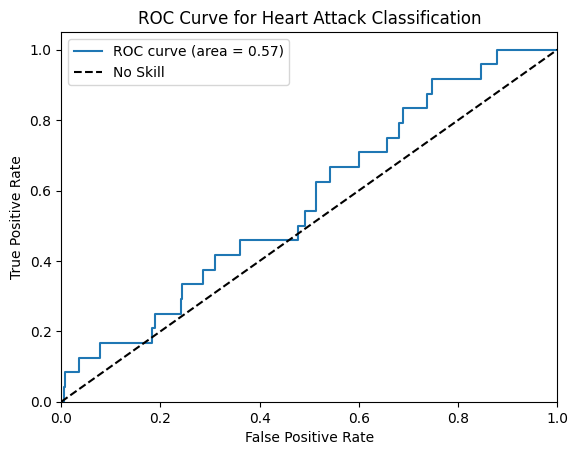

In [ ]:
probs = svc_model.predict_proba(x_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Heart Attack Classification')
plt.legend()
plt.show()

# **Random Forest Algorithm**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(random_state = 5)
random_forest.fit(x_train, y_train.values.ravel())

RandomForestClassifier(random_state=5)

In [ ]:
y_pred = random_forest.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
print("The test accuracy score of Random Forest is", accuracy_score(y_test, y_pred))

The test accuracy score of Random Forest is 0.9530332681017613


In [ ]:
scores = cross_val_score(random_forest, x_test, y_test.values.ravel(), cv = 10)
print("Cross-Validation Accuracy Scores", scores.mean())

Cross-Validation Accuracy Scores 0.9510935143288084


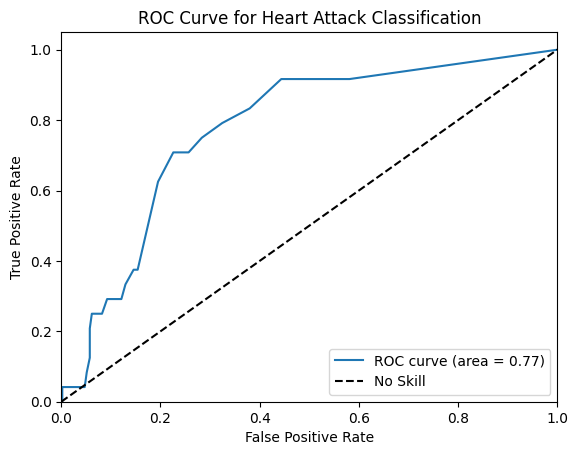

In [ ]:
probs = random_forest.predict_proba(x_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Heart Attack Classification')
plt.legend()
plt.show()

In [ ]:
random_forest_new = RandomForestClassifier(random_state = 5)
random_forest_new

RandomForestClassifier(random_state=5)

In [ ]:
parameters = {"n_estimators" : [50, 100, 150, 200],
              "criterion" : ["gini", "entropy"],
              'max_features': ['auto', 'sqrt', 'log2'],
              'bootstrap': [True, False]}

'''parameters={'n_estimators':[100,200,300,400,500],
            'criterion':['gini', 'entropy'],
            'max_depth':['None',5,10,20,30,40,50,60,70],
            'min_samples_split':[5,10,20,25,30,40,50],
            'max_features':[ 'sqrt', 'log2'],
            'max_leaf_nodes':[5,10,20,25,30,40,50],
            'min_samples_leaf':[1,100,200,300,400,500]
            }'''

"parameters={'n_estimators':[100,200,300,400,500],\n            'criterion':['gini', 'entropy'],\n            'max_depth':['None',5,10,20,30,40,50,60,70],\n            'min_samples_split':[5,10,20,25,30,40,50],\n            'max_features':[ 'sqrt', 'log2'],\n            'max_leaf_nodes':[5,10,20,25,30,40,50],\n            'min_samples_leaf':[1,100,200,300,400,500]\n            }"

In [ ]:
random_forest_grid = GridSearchCV(random_forest_new, param_grid = parameters)

In [ ]:
random_forest_grid.fit(x_train, y_train.values.ravel())

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
80 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/

GridSearchCV(estimator=RandomForestClassifier(random_state=5),
             param_grid={'bootstrap': [True, False],
                         'criterion': ['gini', 'entropy'],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [50, 100, 150, 200]})

In [ ]:
print("Best Parameters:", random_forest_grid.best_params_)

Best Parameters: {'bootstrap': True, 'criterion': 'entropy', 'max_features': 'sqrt', 'n_estimators': 200}


In [ ]:
random_forest_new2 = RandomForestClassifier(bootstrap = True, criterion = "entropy", max_features = "sqrt", n_estimators = 200, random_state = 5)

In [ ]:
random_forest_new2.fit(x_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(criterion='entropy', n_estimators=200, random_state=5)

In [ ]:
y_pred = random_forest_new2.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
print("The test accuracy score of Random Forest after hyper-parameter tuning is:", accuracy_score(y_test, y_pred))

The test accuracy score of Random Forest after hyper-parameter tuning is: 0.9530332681017613


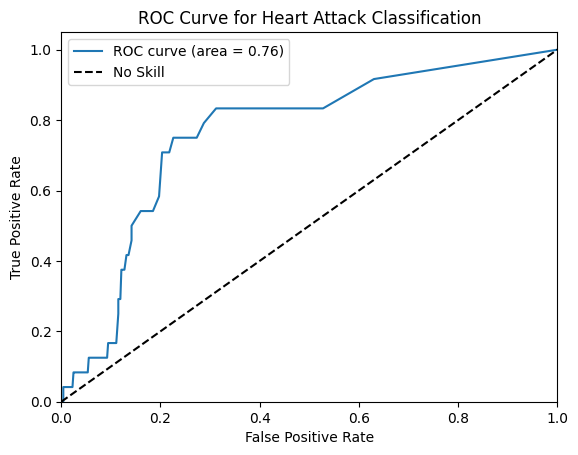

In [ ]:
probs = random_forest_new2.predict_proba(x_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Heart Attack Classification')
plt.legend()
plt.show()

# **RNN**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
x_train = x_train.reshape(x_train.shape[0], 1, x_train.shape[1])
x_test = x_test.reshape(x_test.shape[0], 1, x_test.shape[1])

In [ ]:
model = keras.Sequential([
    layers.SimpleRNN(50, activation='relu', input_shape=(x_train.shape[1], x_train.shape[2])),
    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6145 - loss: 0.6461 - val_accuracy: 0.9457 - val_loss: 0.2422
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9453 - loss: 0.2252 - val_accuracy: 0.9457 - val_loss: 0.1974
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9533 - loss: 0.1727 - val_accuracy: 0.9457 - val_loss: 0.1893
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9517 - loss: 0.1669 - val_accuracy: 0.9457 - val_loss: 0.1858
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9515 - loss: 0.1591 - val_accuracy: 0.9457 - val_loss: 0.1846
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9544 - loss: 0.1468 - val_accuracy: 0.9457 - val_loss: 0.1841
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9540 - loss: 0.1516 - val_accuracy: 0.9457 - val_loss: 0.1841
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9565 - loss: 0.1456 - val_accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Accuracy: {accuracy}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9549 - loss: 0.1586 
Accuracy: 0.9530332684516907


In [ ]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define RNN model
model = Sequential()
model.add(LSTM(units=64, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_data=(x_test, y_test), callbacks=[early_stopping])

# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


144/144 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9482 - loss: 0.0480 - val_accuracy: 0.9530 - val_loss: 0.0422
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9509 - loss: 0.0432 - val_accuracy: 0.9530 - val_loss: 0.0422
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9535 - loss: 0.0406 - val_accuracy: 0.9530 - val_loss: 0.0428
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9476 - loss: 0.0456 - val_accuracy: 0.9530 - val_loss: 0.0428
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9511 - loss: 0.0420 - val_accuracy: 0.9530 - val_loss: 0.0429
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9495 - loss: 0.0430 - val_accuracy: 0.9530 - val_loss: 0.0428
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9549 - loss: 0.0408 
Loss: 0.04218402877449989, Accuracy: 0.9530332684516907


Random Forest Classifier algorithm gave the best accuracy which was similar to a RNN accuracy